# **Rep. 3. Checkpoint 3. Limitaciones de Black-Scholes y modelos alternativos**
- Paola Figueroa
- 22/Marzo/2026

### Modelo de Heston

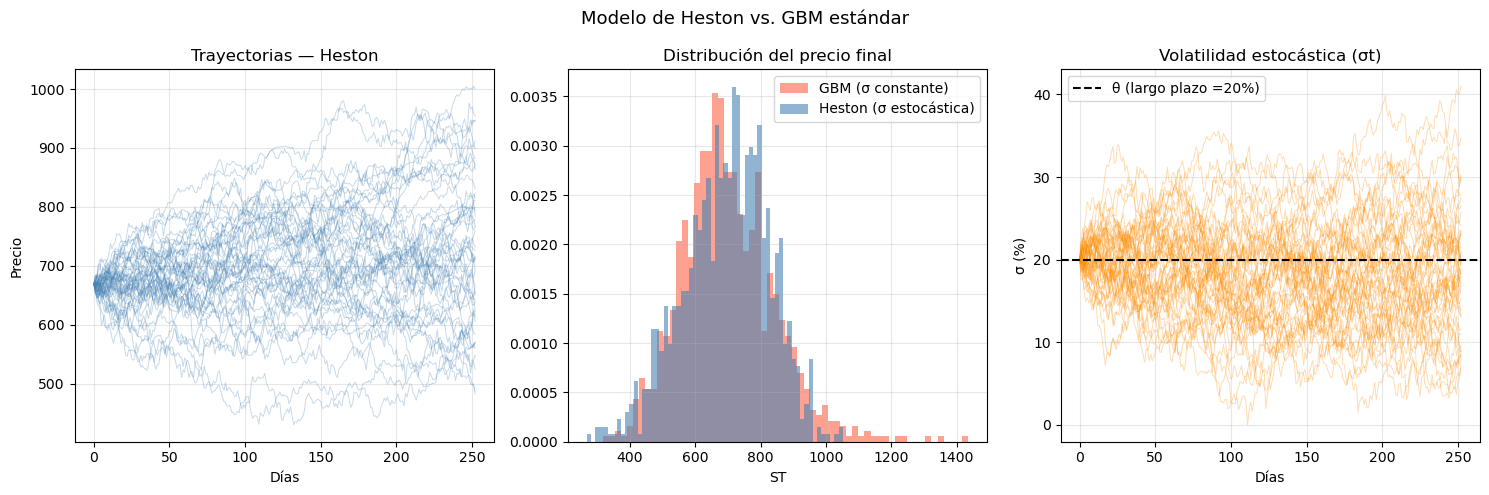

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):
    """
    S0    : precio inicial
    v0    : varianza inicial
    mu    : drift
    kappa : velocidad de reversión
    theta : varianza de largo plazo
    xi    : vol of vol
    rho   : correlación precio-volatilidad
    T     : tiempo en años
    N     : número de pasos
    M     : número de simulaciones
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    v  = np.zeros((M, N + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, N + 1):
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        Zs = Z1
        Zv = rho * Z1 + np.sqrt(1 - rho**2) * Z2  # correlación

        v_pos = np.maximum(v[:, t-1], 0)           # evita varianza negativa

        v[:, t] = (v_pos
                   + kappa * (theta - v_pos) * dt
                   + xi * np.sqrt(v_pos * dt) * Zv)
        v[:, t] = np.maximum(v[:, t], 0)

        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * v_pos) * dt
            + np.sqrt(v_pos * dt) * Zs
        )
    return S, v

# Parámetros
S0    = 669.03
v0    = 0.04
mu    = 0.042
kappa = 2.0
theta = 0.04
xi    = 0.3
rho   = -0.7
T     = 1.0
N     = 252
M     = 1000

S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)

# --- Comparación: GBM estándar vs. Heston ---
sigma_const = 0.20
dt = T / N
Z  = np.random.randn(M, N)
S_gbm = np.zeros((M, N + 1))
S_gbm[:, 0] = S0
for t in range(1, N + 1):
    S_gbm[:, t] = S_gbm[:, t-1] * np.exp(
        (mu - 0.5 * sigma_const**2) * dt + sigma_const * np.sqrt(dt) * Z[:, t-1]
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Trayectorias
for i in range(50):
    axes[0].plot(S_heston[i], alpha=0.3, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Heston')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

# Distribución final: GBM vs Heston
axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM (σ constante)')
axes[1].hist(S_heston[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Heston (σ estocástica)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Evolución de la varianza
for i in range(50):
    axes[2].plot(np.sqrt(v_heston[i]) * 100, alpha=0.3,
                 linewidth=0.7, color='darkorange')
axes[2].axhline(np.sqrt(theta) * 100, color='black',
                linestyle='--', label=f'θ (largo plazo ={np.sqrt(theta)*100:.0f}%)')
axes[2].set_title('Volatilidad estocástica (σt)')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('σ (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Modelo de Heston vs. GBM estándar', fontsize=13)
plt.tight_layout()
plt.show()

### Modelo de Merton

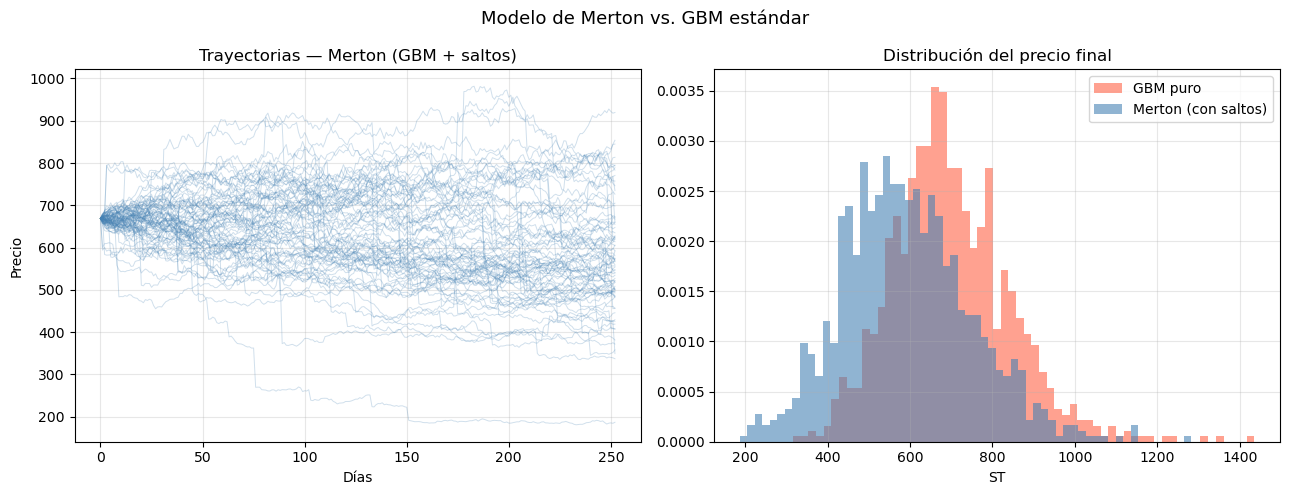

In [2]:
def simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M, seed=42):
    """
    lam     : intensidad de saltos (saltos/año)
    mu_j    : media del log-salto
    sigma_j : desviación del log-salto
    """
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        # Componente difusiva (GBM)
        Z     = np.random.randn(M)
        gbm   = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

        # Componente de saltos (Poisson)
        n_saltos  = np.random.poisson(lam * dt, M)          # número de saltos en dt
        log_salto = np.array([
            np.sum(np.random.normal(mu_j, sigma_j, n))
            if n > 0 else 0.0
            for n in n_saltos
        ])

        S[:, t] = S[:, t-1] * np.exp(gbm + log_salto)

    return S

# Parámetros
S0      = 669.03
mu      = 0.042
sigma   = 0.15
lam     = 4        # ~4 saltos por año
mu_j    = -0.05    # saltos promedio de -5%
sigma_j = 0.10
T       = 1.0
N       = 252
M       = 1000

S_merton = simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias — algunos saltos visibles
for i in range(80):
    axes[0].plot(S_merton[i], alpha=0.25, linewidth=0.7, color='steelblue')
axes[0].set_title('Trayectorias — Merton (GBM + saltos)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].grid(True, alpha=0.3)

# Comparación distribución final
axes[1].hist(S_gbm[:, -1],    bins=60, density=True, alpha=0.6,
             color='tomato',    label='GBM puro')
axes[1].hist(S_merton[:, -1], bins=60, density=True, alpha=0.6,
             color='steelblue', label='Merton (con saltos)')
axes[1].set_title('Distribución del precio final')
axes[1].set_xlabel('ST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Modelo de Merton vs. GBM estándar', fontsize=13)
plt.tight_layout()
plt.show()

## **Variaciones de los modelos**

VARIACIONES HESTON — Xi = 0.1, 0.4, 0.9

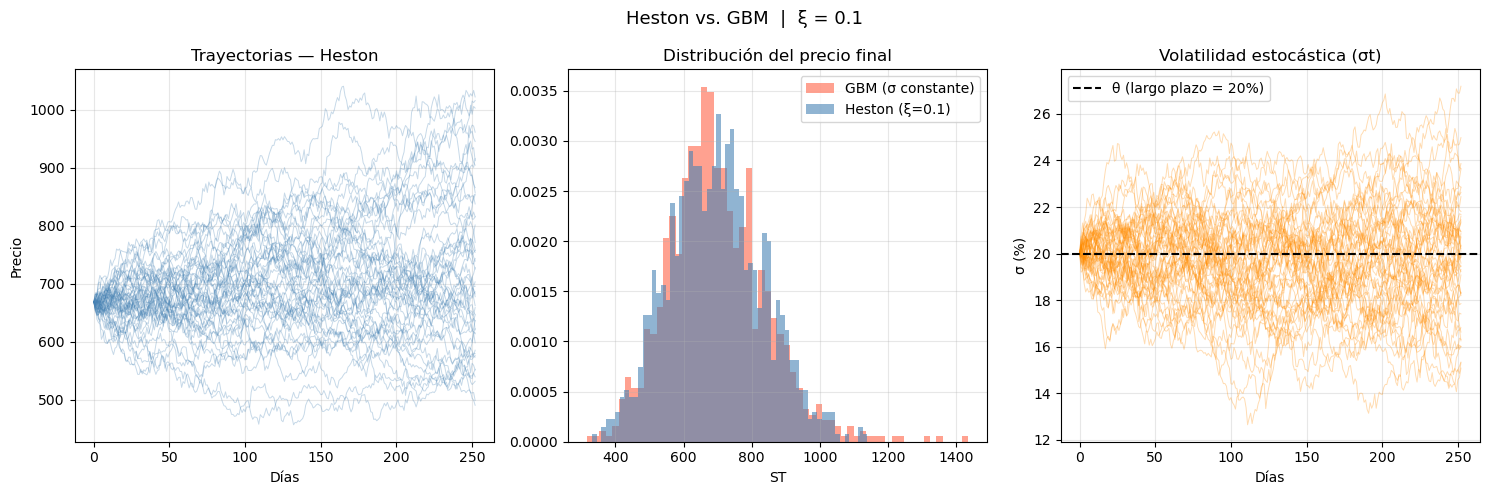

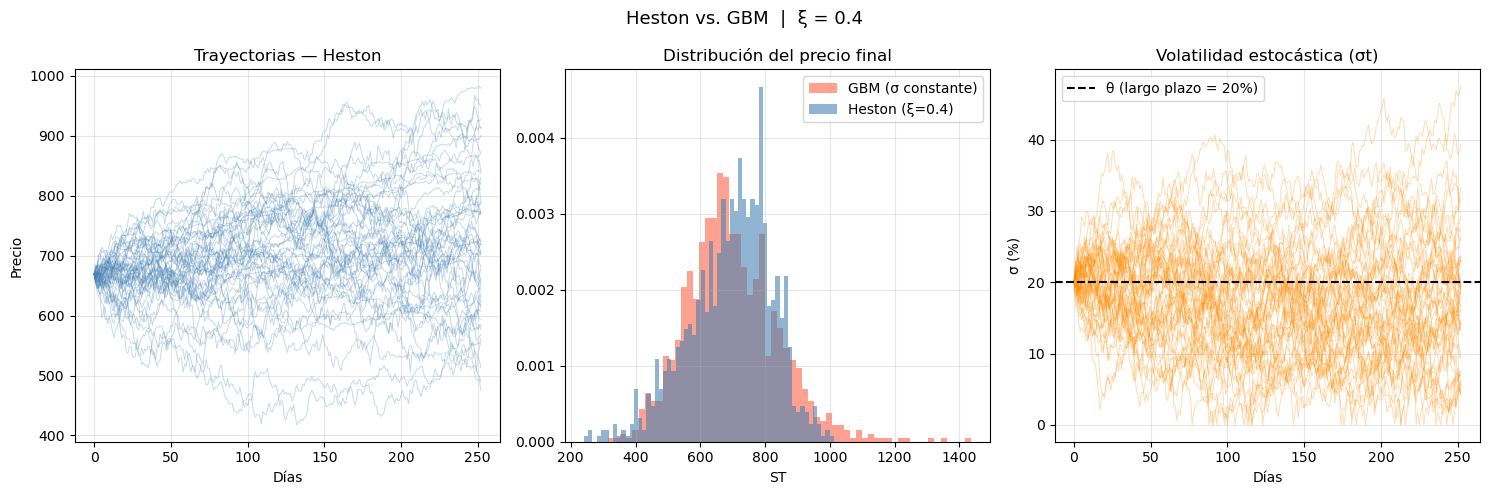

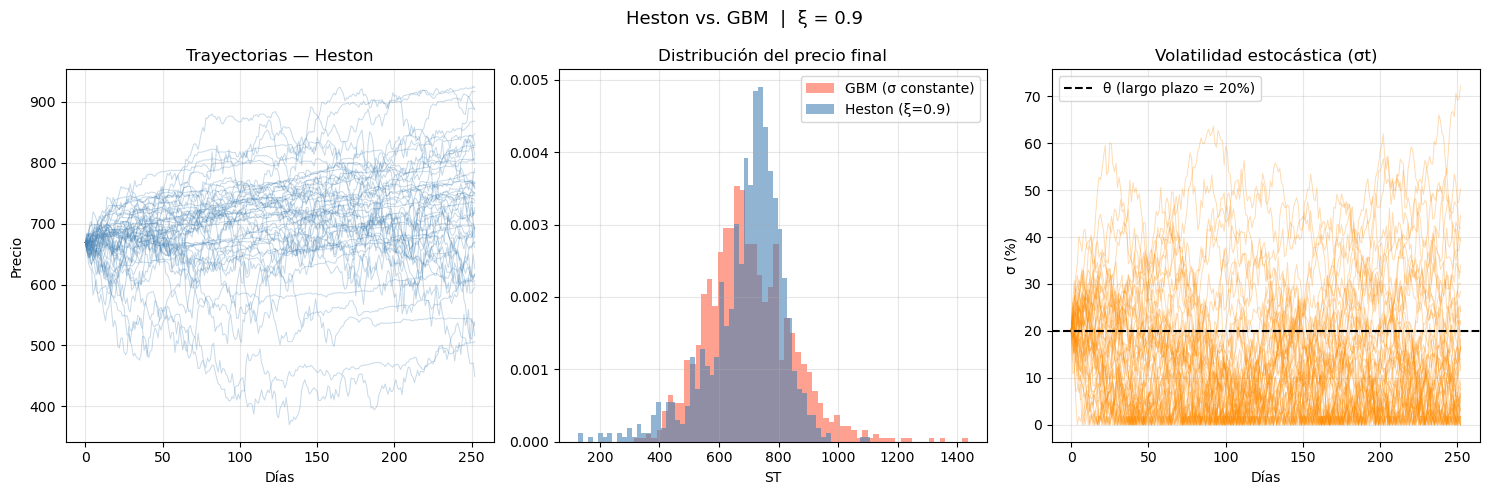

In [3]:
for xi_val in [0.1, 0.4, 0.9]:
    S_h, v_h = simular_heston(S0, v0, mu, kappa, theta, xi_val, rho, T, N, M)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i in range(50):
        axes[0].plot(S_h[i], alpha=0.3, linewidth=0.7, color='steelblue')
    axes[0].set_title('Trayectorias — Heston')
    axes[0].set_xlabel('Días'); axes[0].set_ylabel('Precio'); axes[0].grid(True, alpha=0.3)

    axes[1].hist(S_gbm[:, -1], bins=60, density=True, alpha=0.6, color='tomato',    label='GBM (σ constante)')
    axes[1].hist(S_h[:, -1],   bins=60, density=True, alpha=0.6, color='steelblue', label=f'Heston (ξ={xi_val})')
    axes[1].set_title('Distribución del precio final')
    axes[1].set_xlabel('ST'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    for i in range(50):
        axes[2].plot(np.sqrt(v_h[i]) * 100, alpha=0.3, linewidth=0.7, color='darkorange')
    axes[2].axhline(np.sqrt(theta) * 100, color='black', linestyle='--',
                    label=f'θ (largo plazo = {np.sqrt(theta)*100:.0f}%)')
    axes[2].set_title('Volatilidad estocástica (σt)')
    axes[2].set_xlabel('Días'); axes[2].set_ylabel('σ (%)'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'Heston vs. GBM  |  ξ = {xi_val}', fontsize=13)
    plt.tight_layout()
    plt.show()

VARIACIONES MERTON — lambda = 1, 4, 15

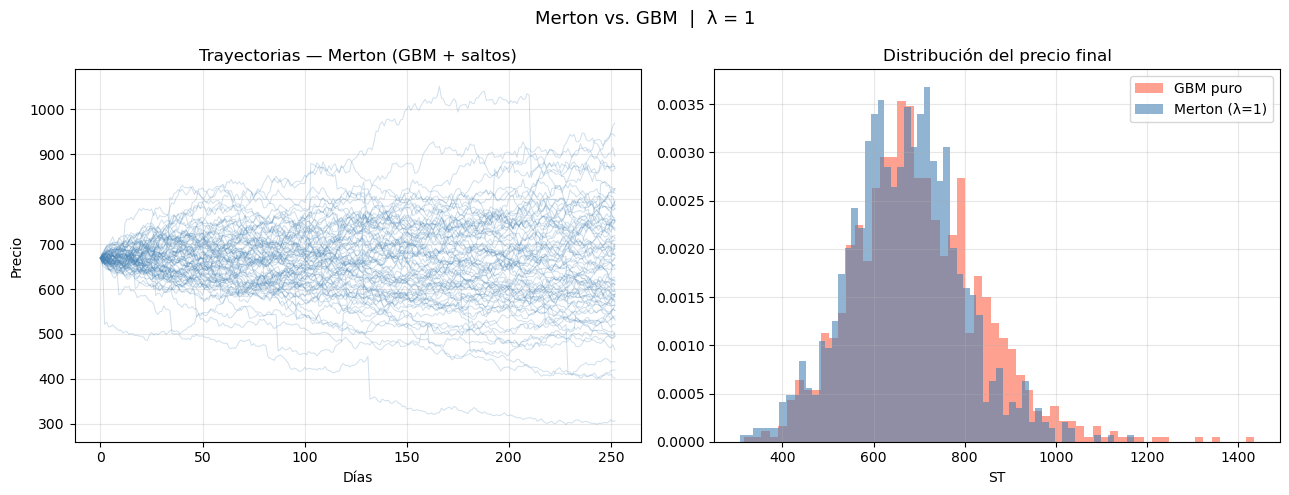

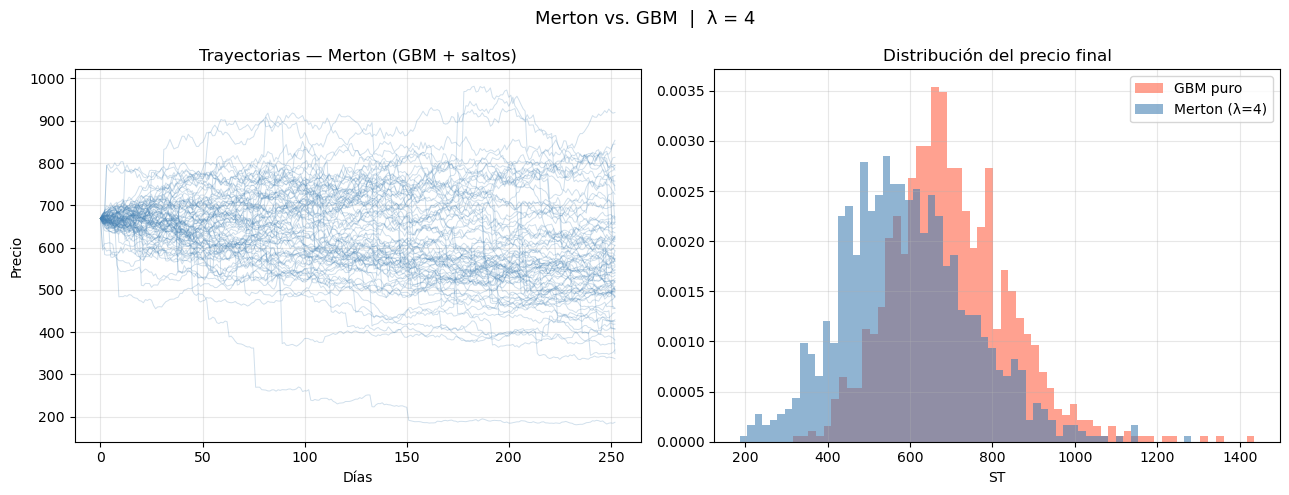

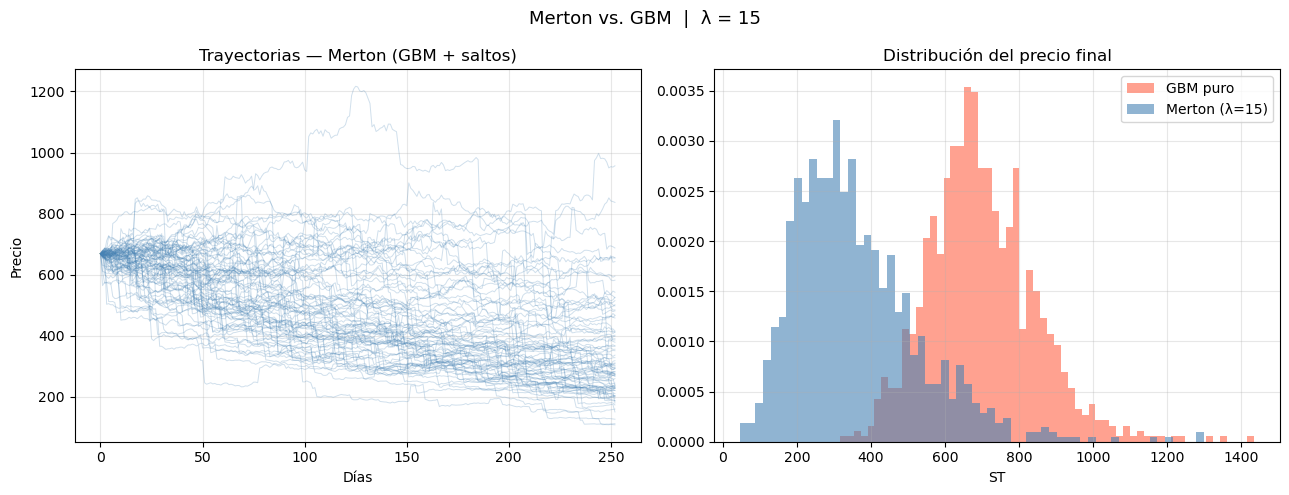

In [4]:
for lam_val in [1, 4, 15]:
    S_m = simular_merton(S0, mu, sigma, lam_val, mu_j, sigma_j, T, N, M)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for i in range(80):
        axes[0].plot(S_m[i], alpha=0.25, linewidth=0.7, color='steelblue')
    axes[0].set_title('Trayectorias — Merton (GBM + saltos)')
    axes[0].set_xlabel('Días'); axes[0].set_ylabel('Precio'); axes[0].grid(True, alpha=0.3)

    axes[1].hist(S_gbm[:, -1], bins=60, density=True, alpha=0.6, color='tomato',    label='GBM puro')
    axes[1].hist(S_m[:, -1],   bins=60, density=True, alpha=0.6, color='steelblue', label=f'Merton (λ={lam_val})')
    axes[1].set_title('Distribución del precio final')
    axes[1].set_xlabel('ST'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Merton vs. GBM  |  λ = {lam_val}', fontsize=13)
    plt.tight_layout()
    plt.show()

## **Preguntas**:
- En la simulación de Heston, ¿qué efecto tiene aumentar ξ (vol of vol) sobre la distribución del precio final? ¿Y sobre el skew?
    - Entre más grande es xi, la volatilidad se vuelve más inestable; más loca. En la distribución final vemos como las colas se ensachan y aparecen precios extremos con mayor frecuencia. Co xi=0.1 la diferencia es casi nula con el movimiento geométrico browniano, pero con xi=0.09, la distribución se aplana y los outliers se vuelven más comunes.
    De la asimetría, vemos como al final tiende más al lado negativo, lo cual es congruente porque cuando el precio cae, la volatilidad sube. Este efecto se amplifica al aumentar el valor de la variable, de manera que la cola izquierda se hace más pesada que la de la derecha, provocando una asimetría negativa más pronunciada. 

- En la simulación de Merton, cambia λ de 4 a 10. ¿Cómo cambian las trayectorias? ¿Y la distribución final?
    - Con más saltos por año las trayectorias se ven más "quebradas", hay más discontinuidades visibles aunque cada salto en sí no cambia. En la distribución final se nota que las colas se ensanchan más y la distribución se aplana. Esto se debe a que la acumulación de saltos negativos va jalando todo hacia el lado izquierdo. 

- Si el mercado tiene fat tails y BS los ignora, ¿en qué dirección estará sesgado el precio BS de un put muy OTM, sobreestimado o subestimado? ¿Por qué?
    - Un put OTM lo usamos como un seguro contra un desplome de mercado, donde solo lo vas a cobrar si el precio cae muchísimo. Como BS asume que los retornos son normales, o sea que los movimientos extremos son rarísimos, a la hora de evaluar cuánto vale un seguro contra un desplome, asume que vale poco, ya que es algo que casi nunca pasa. Sin embargo, en la realidad los desplomes sí pasan más seguido de lo que una normal predice, eso son los fat tails. Entonces el seguro debería ser más caro de lo que BS dice, porque el riesgo real es mayor. En pocas palabras, BS lo está vendiendo barato, por eso en el mercado real los puts OTM siempre tienen una vol implícita más alta que las opciones ATM, porque el mercado ya sabe que BS los está subvaluando y ajusta el precio hacia arriba de forma empírica.

- Merton asume que los saltos son predecibles en frecuencia (λ constante). ¿Qué limitación tiene eso en la práctica?
    - El problema es que en la vida real los crashes no llegan a ritmo uniforme. Se acumulan en épocas de estrés y desaparecen cuando el mercado está tranquilo. Por lo tanto, un lambda fijo no captura ese comportamiento, por lo que habría que usar algún modelo más sofisticado para dejar que este parámetro de lambda varié según lo que ya pasó. 

- ¿Por qué crees que BS sigue siendo el estándar de cotización a pesar de que Heston y Merton son más precisos?
    - Porque, a pesar de estar mal, es más conveniente. Para poder usar Heston y Merton, habría que acordar con la contraparte valores para 5 parámetros antes de cerrar cualquier operación, lo cual al final termina siendo un caos. Es mucho más fácil resumirlo a la volatilidad implícita para que ambas partes se pongan de acuerdo y entiendan de qué están hablando. Black Scoles es el idioma del mercado en el que todos cotizan, cambiarlo requeriría que toda la industria se pusiera de acuerdo al mismo tiempo. Para corregir el hecho de que BS está mal, podemos usar la superficie de volatilidad, es decir calcular una volatilidad implícita para cada precio strike y vencimiento. 
